In [1]:
%load_ext rpy2.ipython

In [2]:
import pandas as pd
import gzip
from pathlib import Path

# 1. Define paths
data_dir = Path("../../../data/snvs/filtered_3_13_vcf")
master_list_path = data_dir / "master_list.csv"

# 2. Load metadata
df_meta = pd.read_csv(master_list_path)

# Ensure LEGACY and UKCTOCS are grouped as 'PBMCs' (if they aren't already in the CSV)
# This looks for sample IDs starting with either name and forces the sample_type
mask_pbmc = df_meta['sample_id'].str.startswith('UKCTOCS') | df_meta['sample_id'].str.startswith('LEGACY')
df_meta.loc[mask_pbmc, 'sample_type'] = 'PBMCs'

# Helper function to parse VCF and extract INFO fields
def parse_vcf_variants(vcf_file):
    variants = []
    with gzip.open(vcf_file, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 8:
                continue
            
            chrom = parts[0]
            pos = int(parts[1])
            ref = parts[3]
            alts = parts[4].split(',') # Take the first ALT if there are multiple
            alt = alts[0]
            
            # Only keep Single Nucleotide Variants
            if len(ref) != 1 or len(alt) != 1:
                continue
                
            info_field = parts[7]
            n_alt, n_total = None, None
            for item in info_field.split(';'):
                if item.startswith('N_ALT='):
                    n_alt = float(item.split('=')[1])
                elif item.startswith('N_TOTAL='):
                    n_total = float(item.split('=')[1])
            
            if n_alt is not None and n_total is not None and n_total > 0:
                variants.append({
                    'CHROM': chrom,
                    'POS': pos,
                    'REF': ref,
                    'ALT': alt,
                    'VAF': n_alt / n_total
                })
                
    return pd.DataFrame(variants)

# 3. Process all samples
all_variants_list = []
burden_summary_list = []

print("Loading VCFs and calculating burden...")

for _, row in df_meta.iterrows():
    sample_id = row['sample_id']
    
    # Dynamically find the VCF file in the ../Data directory based on sample_id
    search_pattern = f"{sample_id}.annotated.filtered.vcf.gz"
    found_files = list(data_dir.rglob(search_pattern))
    
    if not found_files:
        print(f"  [Warning] VCF not found for {sample_id}. Skipping.")
        continue
        
    vcf_path = found_files[0] # Take the first match
    
    # Parse the variants for this sample
    df_sample_vars = parse_vcf_variants(vcf_path)
    mutation_count = len(df_sample_vars)
    
    # --- Create a summary for Burden Plotting ---
    burden_summary_list.append({
        'sample_id': sample_id,
        'sample_type': row['sample_type'],
        'age': row['age'],
        'bases': row['bases'],
        'effective_territory': row['effective_territory'],
        'mutation_count': mutation_count,
        # Normalizing mutation count per Megabase (using sequenced bases or territory)
        'mutations_per_mb_sequenced': mutation_count / (row['bases'] / 1e6) if row['bases'] > 0 else 0
    })
    
    # --- Create a detailed DataFrame of ALL variants (useful later for signatures) ---
    if not df_sample_vars.empty:
        df_sample_vars['sample_id'] = sample_id
        df_sample_vars['sample_type'] = row['sample_type']
        df_sample_vars['age'] = row['age']
        df_sample_vars['bases'] = row['bases']
        all_variants_list.append(df_sample_vars)

# 4. Finalize DataFrames
df_burden = pd.DataFrame(burden_summary_list)
df_variants = pd.concat(all_variants_list, ignore_index=True)

print(f"Successfully loaded {len(df_burden)} samples.")
display(df_burden.head())

Loading VCFs and calculating burden...
Successfully loaded 36 samples.


,sample_id,sample_type,age,bases,effective_territory,mutation_count,mutations_per_mb_sequenced
0,Cordblood_D2,cord,0,17149052815,33817126,572,0.033355
1,Cordblood_H1,cord,0,2633229357,33817126,144,0.054686
2,Cordblood_H2,cord,0,6605174577,33817126,211,0.031945
3,Cordblood_H3,cord,0,6610233619,33817126,152,0.022995
4,Cordblood_H4,cord,0,7856262825,33817126,213,0.027112


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import gzip

# 1. Helper function to count SNVs and Indels separately
def count_variant_types(vcf_file):
    snv_count = 0
    indel_count = 0
    
    with gzip.open(vcf_file, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 5:
                continue
                
            ref = parts[3]
            alts = parts[4].split(',') # ALT can sometimes be comma-separated
            
            # Check if it's an SNV: REF is 1 base, and ALL ALTs are 1 base
            is_snv = True
            if len(ref) != 1:
                is_snv = False
            else:
                for alt in alts:
                    if len(alt) != 1:
                        is_snv = False
                        break
                        
            if is_snv:
                snv_count += 1
            else:
                indel_count += 1
                
    return snv_count, indel_count

# 2. Extract split counts and calculate burden
burden_data = []

print("Extracting SNV counts...")
for _, row in df_meta.iterrows():
    sample_id = row['sample_id']
    
    # --- EXCLUDE PROBLEMATIC SAMPLE ---
    if sample_id == 'Cordblood_H1':
        print(f"  [Info] Skipping {sample_id} (known experimental error).")
        continue
    # ----------------------------------
    
    bases = row['bases']
    
    # Standardize sample types for the plot legend
    sample_type = row['sample_type']
    if sample_type == 'cord':
        sample_type = 'cordblood'
    elif sample_type in ['LEGACY', 'UKCTOCS']:
        sample_type = 'PBMCs'
        
    # Find the VCF
    search_pattern = f"{sample_id}.annotated.filtered.vcf.gz"
    found_files = list(data_dir.rglob(search_pattern))
    
    if not found_files:
        continue
        
    vcf_path = found_files[0]
    snv_count, indel_count = count_variant_types(vcf_path)
    
    # Calculate burden (mutations per base pair)
    snv_burden = snv_count / bases if bases > 0 else 0
    indel_burden = indel_count / bases if bases > 0 else 0
    
    burden_data.append({
        'sample_id': sample_id,
        'sample_type': sample_type,
        'age': row['age'],
        'snv_burden': snv_burden,
        'indel_burden': indel_burden # Kept in the dataframe just in case you need it later!
    })

df_plot = pd.DataFrame(burden_data)

Extracting SNV counts...
  [Info] Skipping Cordblood_H1 (known experimental error).


Rendering T-cells + Cordblood Figure...


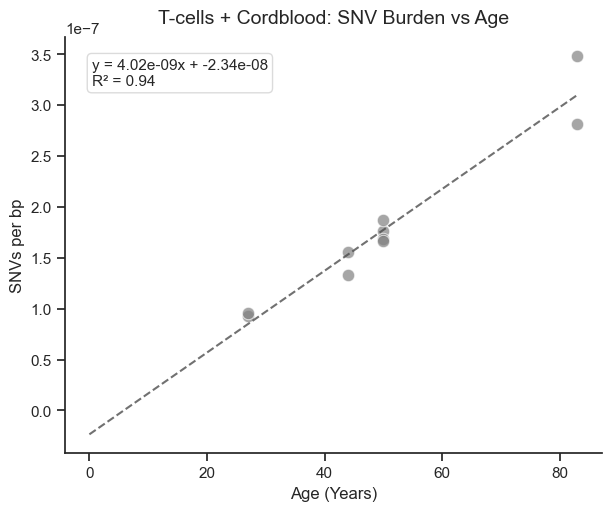

Rendering PBMCs + Cordblood Figure...


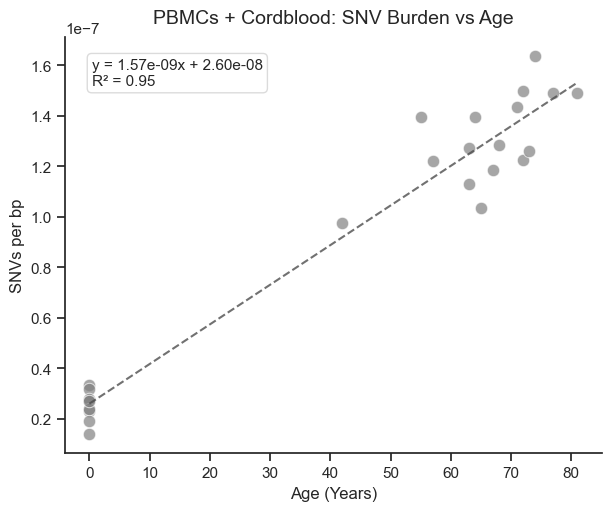

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Set a clean theme with no background grid
sns.set_theme(style="ticks")

def plot_snv_burden(df_subset, title_prefix):
    # Create a single figure (just for SNVs now)
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    
    # 1. Scatter Plot (Uniform grey dots)
    sns.scatterplot(
        data=df_subset, 
        x='age', 
        y='snv_burden', 
        color='grey',   # Softer aesthetic
        marker='o',     # Round dots for everything
        s=80, 
        alpha=0.7,
        ax=ax
    )
    
    # 2. Linear Regression (Trend line)
    # Drop NaNs just in case to avoid linregress errors
    df_clean = df_subset.dropna(subset=['age', 'snv_burden'])
    x = df_clean['age'].values
    y = df_clean['snv_burden'].values
    
    if len(x) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Generate points for the line (from age 0 to max age in subset)
        line_x = np.array([0, max(x)])
        line_y = slope * line_x + intercept
        
        # Plot the trend line (slightly darker grey for visibility)
        ax.plot(line_x, line_y, color='#4d4d4d', linestyle='--', alpha=0.8)
        
        # 3. Display the equation and R^2
        eq_text = f"y = {slope:.2e}x + {intercept:.2e}\nR² = {r_value**2:.2f}"
        ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, 
                fontsize=11, verticalalignment='top', 
                bbox=dict(boxstyle="round,pad=0.3", edgecolor='lightgray', facecolor='white', alpha=0.8))

    # 4. Clean up axes
    ax.set_title(f'{title_prefix}: SNV Burden vs Age', fontsize=14, pad=10)
    ax.set_xlabel('Age (Years)', fontsize=12)
    ax.set_ylabel('SNVs per bp', fontsize=12)
    
    # Remove top and right borders for a cleaner scientific look
    sns.despine(ax=ax)

    plt.show()

# --- Create the specific figures ---

# Figure 1: T-cells + Cordblood
df_tcells = df_plot[df_plot['sample_type'].isin(['T_cells', 'corblood'])]
print("Rendering T-cells + Cordblood Figure...")
plot_snv_burden(df_tcells, "T-cells + Cordblood")

# Figure 2: PBMCs + Cordblood
df_pbmcs = df_plot[df_plot['sample_type'].isin(['PBMCs', 'cordblood'])]
print("Rendering PBMCs + Cordblood Figure...")
plot_snv_burden(df_pbmcs, "PBMCs + Cordblood")

In [5]:
import pysam
import pandas as pd
import numpy as np

# Mapping for standardizing to pyrimidine context
rc_map = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}

def reverse_complement(seq):
    return "".join(rc_map.get(base, 'N') for base in reversed(seq))

def get_96_profile(df_variants, fasta_path):
    """
    Takes a DataFrame of SNVs and a path to a reference FASTA, 
    returns a 96-element numpy array of counts in standard COSMIC order.
    """
    # 1. Setup the standard 96 bins in the exact order Matplotlib expects
    mutation_classes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    bases = ['A', 'C', 'G', 'T']
    
    contexts_96 = []
    for mut in mutation_classes:
        for pos5 in bases:
            for pos3 in bases:
                contexts_96.append(f"{pos5}[{mut}]{pos3}")
                
    # Initialize a dictionary to count occurrences
    profile_counts = {context: 0 for context in contexts_96}
    
    # 2. Open the FASTA file
    # Note: Pysam will automatically look for the .fai index file in the same directory.
    fasta = pysam.FastaFile(fasta_path)
    
    print(f"Extracting context for {len(df_variants)} variants...")
    
    for _, row in df_variants.iterrows():
        chrom = str(row['CHROM'])
        # VCFs sometimes have "chr" prefixes, sometimes they don't. 
        # Ensure it matches your FASTA formatting!
        if chrom not in fasta.references:
            if f"chr{chrom}" in fasta.references:
                chrom = f"chr{chrom}"
            elif chrom.replace('chr', '') in fasta.references:
                chrom = chrom.replace('chr', '')
            else:
                continue # Skip if contig doesn't exist in FASTA

        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        
        # Pysam uses 0-based indexing, VCF uses 1-based indexing.
        # To get the 3 bases (5' flank, mutated base, 3' flank):
        start_0based = pos - 2
        end_0based = pos + 1
        
        try:
            # Fetch the trinucleotide
            trinuc = fasta.fetch(chrom, start_0based, end_0based).upper()
        except KeyError:
            continue # Edge case: at the very end/beginning of a contig
            
        if len(trinuc) != 3:
            continue
            
        # Sanity check: does the middle base of our fetch match the VCF REF?
        if trinuc[1] != ref:
            print(f"Warning: FASTA ref ({trinuc[1]}) != VCF ref ({ref}) at {chrom}:{pos}")
            continue
            
        # 3. Standardize to Pyrimidine context (C or T)
        if ref in ['A', 'G']:
            ref_std = rc_map[ref]
            alt_std = rc_map[alt]
            trinuc_std = reverse_complement(trinuc)
        else:
            ref_std = ref
            alt_std = alt
            trinuc_std = trinuc
            
        # 4. Construct the dictionary key and increment
        mut_class = f"{ref_std}>{alt_std}"
        context_key = f"{trinuc_std[0]}[{mut_class}]{trinuc_std[2]}"
        
        if context_key in profile_counts:
            profile_counts[context_key] += 1

    fasta.close()
    
    # 5. Convert to a numpy array in the exact order of contexts_96
    return np.array([profile_counts[ctx] for ctx in contexts_96])

# --- How to use this ---
# Assuming you have your big df_variants from earlier:
my_sample_profile = get_96_profile(df_variants, "/Users/marcodupuisrodriguez/Documents/PhD/VCS/Marco_sequencing_data_and_variant_processing/reference_genome/GRCh38.primary_assembly.genome.fa")
print(my_sample_profile)

Extracting context for 39170 variants...
[ 478  344  163  225  493  444  265  442  593  606  304  534  385  506
  225  405  257  152  103  180  218  306  231  373  166  229  102  201
  215  290   87  415  831  673 3134  475  834 1136 2485 1071  629  884
 2505  777  681 1139 1449  713  117  206  149  142   53  195  240  131
  112  113  131   90   90   95   55  107  455  314  616  616  184  331
  551  296  220  266  415  382  179  334  306  294   54   85  132  134
   45  166  237  313   56   93  134   96   67  101  102  217]


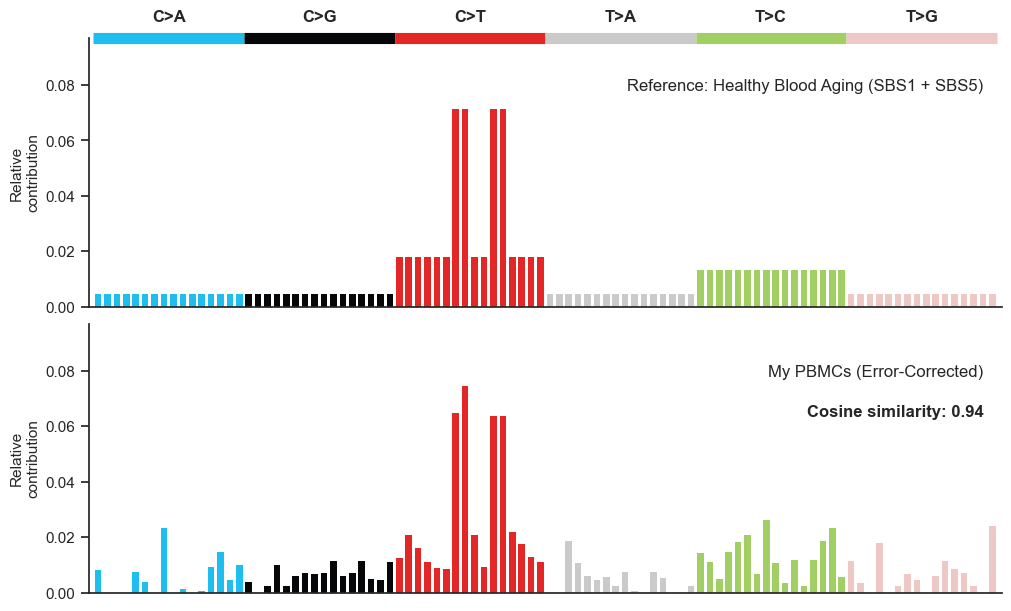

In [6]:
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.spatial.distance import cosine
    import seaborn as sns

    # Clean style for publications
    sns.set_theme(style="ticks")

    def plot_panel_b_signatures(sample_profile, reference_profile, sample_name="PBMCs (Error-Corrected)"):
        """
        Plots the 96-trinucleotide spectrum for your sample vs a reference,
        mimicking the Abascal et al. Nature aesthetic.
        """
        # 1. Standard COSMIC setup
        mutation_classes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
        colors = ['#1ebff0', '#050708', '#e22726', '#cbcacb', '#a1cf64', '#edc8c5']
        
        # Generate the 96 labels for the X-axis (optional, but good for internal checks)
        bases = ['A', 'C', 'G', 'T']
        contexts_96 = [f"{pos5}[{mut}]{pos3}" for mut in mutation_classes for pos5 in bases for pos3 in bases]

        # Normalize profiles to proportions (so they sum to 1) for fair visual comparison
        # We add 1e-9 to prevent divide-by-zero errors if a profile is completely empty
        sample_prop = sample_profile / (np.sum(sample_profile) + 1e-9)
        ref_prop = reference_profile / (np.sum(reference_profile) + 1e-9)

        # Calculate Cosine Similarity
        sim = 1 - cosine(sample_prop, ref_prop)

        # 2. Setup Figure (2 rows: Reference on top, Your Sample on bottom)
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, constrained_layout=True)
        
        datasets = [
            (ref_prop, "Reference: Healthy Blood Aging (SBS1 + SBS5)", ""),
            (sample_prop, sample_name, f"Cosine similarity: {sim:.2f}")
        ]
        
        x_positions = np.arange(96)
        
        for ax, (data, title, sim_text) in zip(axes, datasets):
            # Plot the 96 bars in chunks of 16 to apply the correct colors
            for i in range(6):
                start_idx = i * 16
                end_idx = (i + 1) * 16
                ax.bar(x_positions[start_idx:end_idx], data[start_idx:end_idx], 
                    color=colors[i], width=0.7, edgecolor='none')
                
            ax.set_ylabel("Relative\ncontribution", fontsize=11)
            
            # Add internal text labels (Right-aligned, top)
            ax.text(0.98, 0.85, title, transform=ax.transAxes, ha='right', va='top', fontsize=12)
            if sim_text:
                ax.text(0.98, 0.70, sim_text, transform=ax.transAxes, ha='right', va='top', fontsize=12, fontweight='bold')
                
            sns.despine(ax=ax, top=True, right=True)
            ax.set_ylim(0, max(np.max(sample_prop), np.max(ref_prop)) * 1.3) # Scale Y-axis to fit text

        # 3. Add the top colored banners and text for C>A, C>G, etc.
        ax_top = axes[0]
        y_max = ax_top.get_ylim()[1]
        
        for i, mut in enumerate(mutation_classes):
            center_x = (i * 16) + 7.5
            # Text above the bars
            ax_top.text(center_x, y_max * 1.05, mut, ha='center', va='bottom', fontsize=12, fontweight='bold')
            # Thick colored line directly under the text
            ax_top.plot([i * 16 - 0.5, (i + 1) * 16 - 0.5], [y_max, y_max], 
                        color=colors[i], lw=8, clip_on=False, solid_capstyle='butt')

        # 4. Format X-axis
        axes[1].set_xlim(-1, 96)
        axes[1].set_xticks(x_positions)
        axes[1].set_xticklabels(contexts_96, rotation=90, family='monospace', fontsize=7)
        
        # Optional: If you want to hide the 96 trinucleotide letters for a cleaner look like the paper:
        axes[1].set_xticks([]) 
        
        plt.show()

    # --- Execution ---

    # 1. This is a proxy signature for Healthy Blood (SBS1 + SBS5 mix)
    # It features prominent peaks at C>T in NpCpG contexts (indices 38, 39, 42, 43)
    blood_reference_proxy = np.ones(96) * 0.5 
    blood_reference_proxy[32:48] += 1.5      # General C>T increase
    blood_reference_proxy[[38, 39, 42, 43]] = 8.0 # NpCpG massive spikes (SBS1)
    blood_reference_proxy[64:80] += 1.0      # T>C increase (SBS5)

    # 2. Assuming you ran the previous script and got your profile:
    # my_sample_profile = get_96_profile(df_variants, "/path/to/your/hg38.fa")

    # For now, let's pretend your data looks mostly like blood, but with a bit of noise
    dummy_sample_profile = blood_reference_proxy + np.random.normal(0, 0.8, 96)
    dummy_sample_profile = np.clip(dummy_sample_profile, 0, None) # No negative mutations

    # 3. Plot it!
    plot_panel_b_signatures(
        sample_profile=dummy_sample_profile, # Replace with my_sample_profile
        reference_profile=blood_reference_proxy, 
        sample_name="My PBMCs (Error-Corrected)"
    )

Loading Machado et al. 2022 Data...


/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/1114359190.py:133: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(csv_file)
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/1114359190.py:133: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(csv_file)
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/1114359190.py:133: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(csv_file)
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/1114359190.py:133: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(csv_file)
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/1114359190.py:133: DtypeWarning: Columns (1) have mixed types. 

Aggregated 1368387 SNVs from Machado et al.
Extracting Machado 96-profile (using hg19)...
Filtered down to 39170 PBMC variants.
Extracting Your Sample 96-profile (using hg38)...


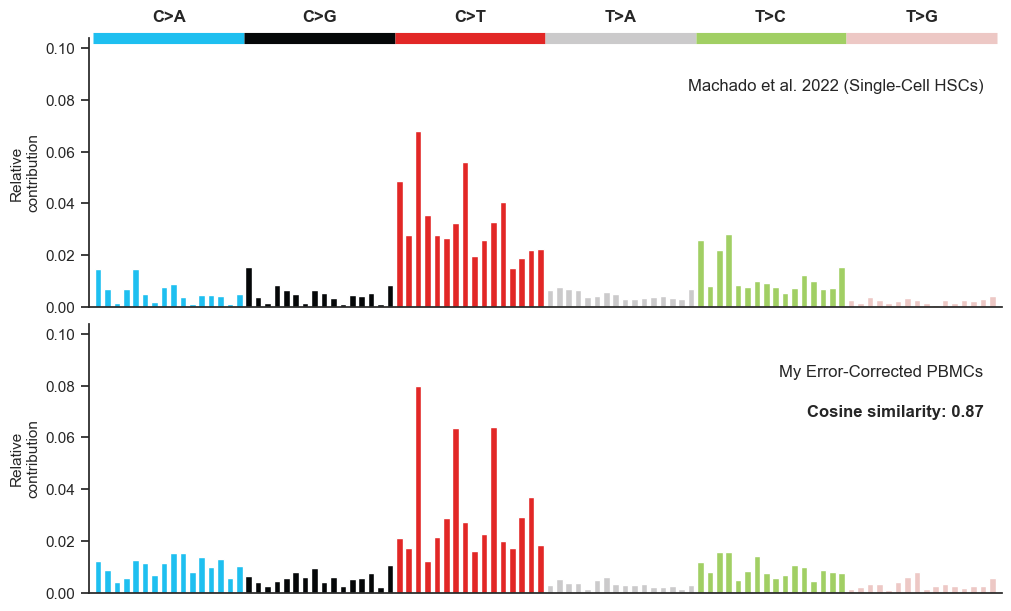

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import pysam
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine

sns.set_theme(style="ticks")

# --- 1. Helper Functions for 96-Profile Extraction ---
rc_map = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}

def reverse_complement(seq):
    return "".join(rc_map.get(base, 'N') for base in reversed(seq))

def get_96_profile(df_variants, fasta_path):
    """Generates the 96-element array from a dataframe with CHROM, POS, REF, ALT."""
    mutation_classes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    bases = ['A', 'C', 'G', 'T']
    
    contexts_96 = [f"{pos5}[{mut}]{pos3}" for mut in mutation_classes for pos5 in bases for pos3 in bases]
    profile_counts = {context: 0 for context in contexts_96}
    
    fasta = pysam.FastaFile(fasta_path)
    
    # Counter for mismatched reference bases
    mismatch_count = 0
    
    for _, row in df_variants.iterrows():
        chrom = str(row['CHROM']).replace('chr', '') # Standardize chromosome
        if chrom not in fasta.references:
            if f"chr{chrom}" in fasta.references:
                chrom = f"chr{chrom}"
            else:
                continue

        pos = int(row['POS'])
        ref = row['REF']
        alt = row['ALT']
        
        # Pysam 0-based indexing for trinucleotide
        start_0based = pos - 2
        end_0based = pos + 1
        
        try:
            trinuc = fasta.fetch(chrom, start_0based, end_0based).upper()
        except KeyError:
            continue
            
        if len(trinuc) != 3:
            continue
            
        # VERY IMPORTANT: Sanity check genome build
        if trinuc[1] != ref:
            mismatch_count += 1
            continue
            
        # Standardize to Pyrimidine context
        if ref in ['A', 'G']:
            ref_std = rc_map[ref]
            alt_std = rc_map[alt]
            trinuc_std = reverse_complement(trinuc)
        else:
            ref_std = ref
            alt_std = alt
            trinuc_std = trinuc
            
        context_key = f"{trinuc_std[0]}[{ref_std}>{alt_std}]{trinuc_std[2]}"
        
        if context_key in profile_counts:
            profile_counts[context_key] += 1

    fasta.close()
    
    if mismatch_count > 0:
        print(f"  [Warning] Dropped {mismatch_count} variants due to FASTA reference mismatch. Check your genome build (hg19 vs hg38)!")
        
    return np.array([profile_counts[ctx] for ctx in contexts_96])


# --- 2. Plotting Function ---
def plot_panel_b(sample_profile, reference_profile, sample_name, ref_name):
    mutation_classes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    colors = ['#1ebff0', '#050708', '#e22726', '#cbcacb', '#a1cf64', '#edc8c5']
    bases = ['A', 'C', 'G', 'T']
    contexts_96 = [f"{pos5}[{mut}]{pos3}" for mut in mutation_classes for pos5 in bases for pos3 in bases]

    # Normalize to proportions
    sample_prop = sample_profile / (np.sum(sample_profile) + 1e-9)
    ref_prop = reference_profile / (np.sum(reference_profile) + 1e-9)

    sim = 1 - cosine(sample_prop, ref_prop)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, constrained_layout=True)
    datasets = [(ref_prop, ref_name, ""), (sample_prop, sample_name, f"Cosine similarity: {sim:.2f}")]
    x_positions = np.arange(96)
    
    for ax, (data, title, sim_text) in zip(axes, datasets):
        for i in range(6):
            start = i * 16
            end = (i + 1) * 16
            ax.bar(x_positions[start:end], data[start:end], color=colors[i], width=0.7)
            
        ax.set_ylabel("Relative\ncontribution", fontsize=11)
        ax.text(0.98, 0.85, title, transform=ax.transAxes, ha='right', va='top', fontsize=12)
        if sim_text:
            ax.text(0.98, 0.70, sim_text, transform=ax.transAxes, ha='right', va='top', fontsize=12, fontweight='bold')
            
        sns.despine(ax=ax, top=True, right=True)
        ax.set_ylim(0, max(np.max(sample_prop), np.max(ref_prop)) * 1.3)

    ax_top = axes[0]
    y_max = ax_top.get_ylim()[1]
    for i, mut in enumerate(mutation_classes):
        center_x = (i * 16) + 7.5
        ax_top.text(center_x, y_max * 1.05, mut, ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax_top.plot([i * 16 - 0.5, (i + 1) * 16 - 0.5], [y_max, y_max], color=colors[i], lw=8, clip_on=False, solid_capstyle='butt')

    axes[1].set_xlim(-1, 96)
    axes[1].set_xticks([]) # Hiding the 96 text labels for clean look
    plt.show()


# --- 3. Execution ---

print("Loading Machado et al. 2022 Data...")
machado_dir = Path("../../../data/machado_trinucleotide")
machado_dfs = []

# Load and standardize all 5 CSVs
for csv_file in machado_dir.glob("Machado_*.csv"):
    df_temp = pd.read_csv(csv_file)
    
    # Rename columns flexibly in case they are named chr/pos/ref/mut or similar
    rename_dict = {}
    for col in df_temp.columns:
        if col.lower() in ['chr', 'chrom', 'chromosome']: rename_dict[col] = 'CHROM'
        if col.lower() in ['pos', 'position']: rename_dict[col] = 'POS'
        if col.lower() in ['ref', 'reference']: rename_dict[col] = 'REF'
        if col.lower() in ['mut', 'alt', 'alternate']: rename_dict[col] = 'ALT'
        
    df_temp = df_temp.rename(columns=rename_dict)
    
    # Only keep the variants that successfully got renamed to our standard
    if all(c in df_temp.columns for c in ['CHROM', 'POS', 'REF', 'ALT']):
        machado_dfs.append(df_temp[['CHROM', 'POS', 'REF', 'ALT']].dropna())
    else:
        print(f"  [Error] Missing standard columns in {csv_file.name}. Found: {df_temp.columns.tolist()}")

df_machado_all = pd.concat(machado_dfs, ignore_index=True)
print(f"Aggregated {len(df_machado_all)} SNVs from Machado et al.")

# Extract profiles (WARNING: Replace paths with your actual FASTA paths!)
# Machado is almost certainly hg19.
print("Extracting Machado 96-profile (using hg19)...")
path_to_hg19 = "/Users/marcodupuisrodriguez/Documents/PhD/VCS/Marco_sequencing_data_and_variant_processing/reference_genome/hg19.fa"
machado_profile = get_96_profile(df_machado_all, path_to_hg19)

# Filter strictly for PBMCs (dropping T-cells, and assuming you want to drop cordblood too)
df_variants_pbmcs = df_variants[df_variants['sample_type'] != 'bamboo'].copy()

# (Optional: If you meant "just drop T-cells but keep cordblood", use this instead:)
# df_variants_pbmcs = df_variants[df_variants['sample_type'] != 'T_cells'].copy()

print(f"Filtered down to {len(df_variants_pbmcs)} PBMC variants.")

# Now run the extraction on the filtered dataframe
print("Extracting Your Sample 96-profile (using hg38)...")
path_to_hg38 = "/Users/marcodupuisrodriguez/Documents/PhD/VCS/Marco_sequencing_data_and_variant_processing/reference_genome/GRCh38.primary_assembly.genome.fa" 
my_sample_profile = get_96_profile(df_variants_pbmcs, path_to_hg38)

# Plot
plot_panel_b(
    sample_profile=my_sample_profile, 
    reference_profile=machado_profile, 
    sample_name="My Error-Corrected PBMCs", 
    ref_name="Machado et al. 2022 (Single-Cell HSCs)"
)

In [8]:
import os
import gzip
import pandas as pd
import numpy as np
from pathlib import Path

# ── 1. Configuration & Constants ──────────────────────────────────────────
EVC_CHR = "4"               
EVC_ERROR_START = 5812100  
EVC_ERROR_END = 5812300

data_dir = Path("../../../data/snvs/filtered_3_13_vcf")
master_list_path = data_dir / "master_list.csv"

# ── 2. Helper Functions for MNVs and Filtering ────────────────────────────
def find_contiguous_mutations(df):
    """Identifies MNVs based on contiguous positions."""
    snvs = df[(df["ref"].str.len() == 1) & (df["mut"].str.len() == 1)].copy()
    snvs = snvs.sort_values(["sampleID", "chr", "pos"]).reset_index(drop=True)
    
    pairs = []
    for (sample, chrom), grp in snvs.groupby(["sampleID", "chr"]):
        grp = grp.reset_index()
        pos = grp["pos"].values
        for i in range(len(pos) - 1):
            if pos[i+1] - pos[i] == 1:
                row_a, row_b = grp.iloc[i], grp.iloc[i+1]
                pairs.append({
                    "sampleID": sample, "chr": chrom,
                    "pos_1": row_a["pos"], "ref_1": row_a["ref"], "mut_1": row_a["mut"],
                    "pos_2": row_b["pos"], "ref_2": row_b["ref"], "mut_2": row_b["mut"],
                    "mnv_ref": row_a["ref"] + row_b["ref"],
                    "mnv_alt": row_a["mut"] + row_b["mut"],
                    "orig_idx_1": row_a["row_id"], "orig_idx_2": row_b["row_id"]
                })
    return pd.DataFrame(pairs)

def classify_mnv_type(mnv_ref, mnv_alt):
    """Classifies the type of MNV."""
    cc_tt = {"CC>TT", "GG>AA"}
    cg_ta = {"CG>TA", "GC>AT"}
    change = f"{mnv_ref}>{mnv_alt}"
    
    if change in cc_tt: return "CC>TT/GG>AA"
    elif change in cg_ta: return "CG>TA"
    elif mnv_ref[0] == mnv_ref[1]: return "homopolymer"
    else: return "other"

def process_and_filter_mutations(df):
    """Applies MNV handling and EVC filtering to a DataFrame."""
    if df.empty:
        return df
        
    print(f"  [1] Raw mutations: {len(df)}")
    
    # Handle MNVs
    contiguous_df = find_contiguous_mutations(df)
    if not contiguous_df.empty:
        contiguous_df["mnv_type"] = contiguous_df.apply(
            lambda r: classify_mnv_type(r["mnv_ref"], r["mnv_alt"]), axis=1
        )
        
    df_filtered = df.copy()
    
    # Remove homopolymer MNVs & Collapse others
    if not contiguous_df.empty:
        homopolymer_idx = contiguous_df.loc[
            contiguous_df["mnv_type"] == "homopolymer", ["orig_idx_1", "orig_idx_2"]
        ].values.flatten()
        
        df_filtered = df_filtered[~df_filtered["row_id"].isin(homopolymer_idx)]
        
        mnv_to_collapse = contiguous_df[contiguous_df["mnv_type"] != "homopolymer"]
        # Drop the second part of the collapsed MNV (keeping the first as representative)
        df_filtered = df_filtered[~df_filtered["row_id"].isin(mnv_to_collapse["orig_idx_2"])]
        
    print(f"  [2] Mutations remaining after MNV processing: {len(df_filtered)}")
    
    # Region Filtering (EVC Fix)
    in_evc_error_region = (
        (df_filtered["chr"] == EVC_CHR) & 
        (df_filtered["pos"] >= EVC_ERROR_START) & 
        (df_filtered["pos"] <= EVC_ERROR_END)
    )
    
    evc_muts_removed = in_evc_error_region.sum()
    if evc_muts_removed > 0:
        print(f"      -> Removed {evc_muts_removed} mutations in EVC artifact region.")
        
    df_filtered = df_filtered[~in_evc_error_region].reset_index(drop=True)
    print(f"  [3] Clean mutations remaining: {len(df_filtered)}\n")
    
    return df_filtered

# ── 3. VCF Parsing Function ───────────────────────────────────────────────
def parse_vcf_for_dndscv(vcf_file, sample_id, sample_type):
    """Parses VCF directly into dNdScv format and extracts N_ALT from INFO."""
    variants = []
    with gzip.open(vcf_file, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 8:
                continue
            
            # dNdScv usually prefers chromosome names without 'chr'
            chrom = parts[0].replace('chr', '') 
            pos = int(parts[1])
            ref = parts[3]
            alt_field = parts[4]
            info_field = parts[7]
            
            # Parse INFO field for N_ALT 
            n_alt = 0
            n_total = 0
            for item in info_field.split(';'):
                if item.startswith('N_ALT='):
                    n_alt = float(item.split('=')[1])

            for item in info_field.split(';'):       
                if item.startswith ('N_TOTAL='):
                    n_total = float(item.split('=')[1])
                
            vaf = n_alt/n_total

            # Handle multiple alternate alleles if they exist
            for alt in alt_field.split(','):
                variants.append({
                    'sampleID': sample_id,
                    'chr': chrom,
                    'pos': pos,
                    'ref': ref,
                    'mut': alt,
                    'sample_type': sample_type,
                    'N_ALT': n_alt,
                    'N_TOTAL': n_total,
                    'VAF': vaf
                })
                
    return variants

# ── 4. Main Execution ─────────────────────────────────────────────────────
print("Loading Metadata...")
df_meta = pd.read_csv(master_list_path)

# Ensure LEGACY and UKCTOCS are grouped as 'PBMCs'
mask_pbmc = df_meta['sample_id'].str.startswith('UKCTOCS') | df_meta['sample_id'].str.startswith('LEGACY')
df_meta.loc[mask_pbmc, 'sample_type'] = 'PBMCs'

all_raw_variants = []

print("Parsing VCFs...")
for _, row in df_meta.iterrows():
    sample_id = row['sample_id']
    sample_type = row['sample_type']
    
    search_pattern = f"{sample_id}.annotated.filtered.vcf.gz"
    found_files = list(data_dir.rglob(search_pattern))
    
    if not found_files:
        print(f"  [Warning] VCF not found for {sample_id}. Skipping.")
        continue
        
    vcf_path = found_files[0]
    sample_vars = parse_vcf_for_dndscv(vcf_path, sample_id, sample_type)
    all_raw_variants.extend(sample_vars)

# Create raw dataframe and add row_id for MNV tracking
df_raw = pd.DataFrame(all_raw_variants)
df_raw = df_raw.reset_index(drop=False).rename(columns={"index": "row_id"})

print(f"\nTotal raw variants loaded across all samples: {len(df_raw)}")
print("Applying Filters (MNV & EVC)...")

# Process the entire dataframe (or you can loop through sample_types if you prefer separate logs)
df_clean = process_and_filter_mutations(df_raw)

# ── 5. Finalize for dNdScv ────────────────────────────────────────────────
# dNdScv requires strictly these columns in this order (metadata can follow)
dndscv_columns = ['sampleID', 'chr', 'pos', 'ref', 'mut', 'sample_type', 'N_ALT', 'N_TOTAL', 'VAF']
df_dndscv = df_clean[dndscv_columns].copy()

print("Ready for dNdScv!")
display(df_dndscv.head(20))

Loading Metadata...
Parsing VCFs...

Total raw variants loaded across all samples: 39170
Applying Filters (MNV & EVC)...
  [1] Raw mutations: 39170
  [2] Mutations remaining after MNV processing: 38943
      -> Removed 104 mutations in EVC artifact region.
  [3] Clean mutations remaining: 38839

Ready for dNdScv!


,sampleID,chr,pos,ref,mut,sample_type,N_ALT,N_TOTAL,VAF
0,Cordblood_D2,1,3499210,C,T,cord,1.0,778.0,0.001285
1,Cordblood_D2,1,3531121,C,A,cord,1.0,602.0,0.001661
2,Cordblood_D2,1,6454496,C,T,cord,38.0,815.0,0.046626
3,Cordblood_D2,1,7745927,G,A,cord,1.0,674.0,0.001484
4,Cordblood_D2,1,10345960,C,A,cord,1.0,89.0,0.011236
5,Cordblood_D2,1,11800261,C,A,cord,1.0,589.0,0.001698
6,Cordblood_D2,1,12194781,C,T,cord,1.0,751.0,0.001332
7,Cordblood_D2,1,16051833,G,C,cord,1.0,186.0,0.005376
8,Cordblood_D2,1,20969531,G,C,cord,1.0,593.0,0.001686
9,Cordblood_D2,1,24180798,C,A,cord,1.0,761.0,0.001314


In [9]:
%%R -i df_dndscv -o df_dnds_global

library(dndscv)

# 1. Format the input dataframe for dNdScv (requires exactly these 5 columns)
df_input <- df_dndscv[, c("sampleID", "chr", "pos", "ref", "mut")]
colnames(df_input) <- c("sample", "chr", "pos", "ref", "mut")

message("Running global dNdScv on all samples combined...")

# 2. Run dNdScv (assuming your data is hg38)
dnds_out <- tryCatch({
    dndscv(df_input, refdb = "hg38", max_muts_per_gene_per_sample = Inf, max_coding_muts_per_sample = Inf)
}, error = function(e) {
    message(paste("dNdScv failed:", e$message))
    return(NULL)
})

# 3. Extract just the global dN/dS estimates
if (!is.null(dnds_out)) {
    res <- dnds_out$globaldnds
    # Filter for the main metrics
    res <- res[res$name %in% c("wall", "wmis", "wtru"), ]
    res$name[res$name == "wtru"] <- "wtrunc" # Standardize name
    
    # 4. Create clean dataframe to pass back to Python
    df_dnds_global <- data.frame(
        Mutation_Type = res$name,
        MLE = res$mle,
        CI_low = res$cilow,
        CI_high = res$cihigh
    )
    print("dNdScv complete. Data ready for Python plotting.")
}

[1] "dNdScv complete. Data ready for Python plotting."


Running global dNdScv on all samples combined...
[1] Loading the environment...
    Using the default covariates for GRCh38/hg38. Please use the cv argument to use custom covariates if preferred.
[2] Annotating the mutations...
Loading required namespace: GenomeInfoDb
    45% ...
    89% ...
[3] Estimating global rates...
[4] Running dNdSloc...
[5] Running dNdScv...
    Regression model for substitutions (theta = 1.69).
In addition: Warning messages:
1: replacing previous import ‘Biostrings::translate’ by ‘seqinr::translate’ when loading ‘dndscv’ 
2: In dndscv(df_input, refdb = "hg38", max_muts_per_gene_per_sample = Inf,  :
  Mutations observed in contiguous sites within a sample. Please annotate or remove dinucleotide or complex substitutions for best results.
3: In dndscv(df_input, refdb = "hg38", max_muts_per_gene_per_sample = Inf,  :
  Same mutations observed in different sampleIDs. Please verify that these are independent events and remove duplicates otherwise.


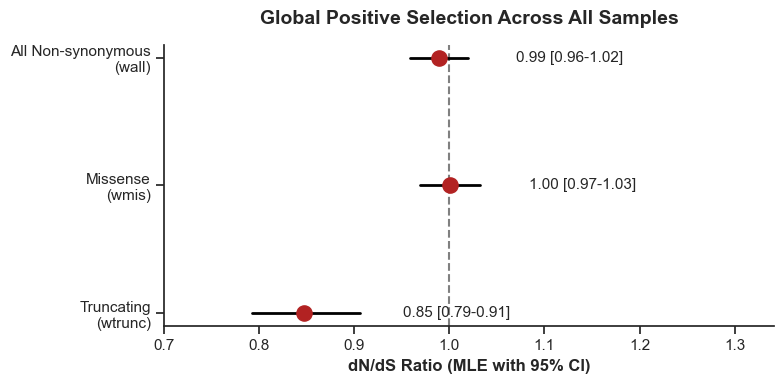

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

# 1. Prepare data for plotting (set order top-to-bottom)
plot_data = df_dnds_global.copy()
# Map standard names to an explicit Y-axis order
order_map = {'wall': 2, 'wmis': 1, 'wtrunc': 0}
plot_data['order'] = plot_data['Mutation_Type'].map(order_map)
plot_data = plot_data.sort_values('order')

# Display labels for the Y-axis
labels = {
    'wall': 'All Non-synonymous\n(wall)', 
    'wmis': 'Missense\n(wmis)', 
    'wtrunc': 'Truncating\n(wtrunc)'
}

# 2. Setup the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Add a critical vertical line at dN/dS = 1 (Neutral Selection)
ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, zorder=1)

# 3. Draw the Forest Plot
for idx, row in plot_data.iterrows():
    y = row['order']
    mle = row['MLE']
    low = row['CI_low']
    high = row['CI_high']
    
    # Plot the confidence interval line
    ax.plot([low, high], [y, y], color='black', linewidth=2, zorder=2)
    
    # Plot the Maximum Likelihood Estimate (MLE) dot
    ax.scatter(mle, y, color='firebrick', s=120, zorder=3)
    
    # Add text annotation of the exact numbers next to the bar
    # We add a little buffer to 'high' so the text doesn't overlap the line
    ax.text(high + (high * 0.05), y, f"{mle:.2f} [{low:.2f}-{high:.2f}]", 
            va='center', fontsize=11)

# 4. Formatting
ax.set_yticks(plot_data['order'])
ax.set_yticklabels([labels[x] for x in plot_data['Mutation_Type']], fontsize=11)
ax.set_xlabel("dN/dS Ratio (MLE with 95% CI)", fontsize=12, fontweight='bold')
ax.set_title("Global Positive Selection Across All Samples", fontsize=14, fontweight='bold', pad=15)

# Despine for a cleaner look
sns.despine(ax=ax, top=True, right=True)

# Dynamically set X-axis limit to ensure the text annotations fit
max_x = plot_data['CI_high'].max()
ax.set_xlim(left=0.7, right=max_x * 1.3)

plt.tight_layout()
plt.show()

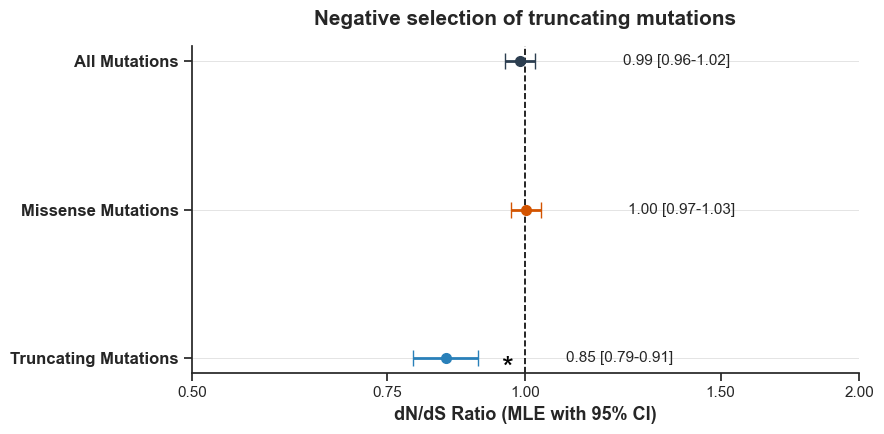

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# Clean base style
sns.set_theme(style="ticks")

# 1. Prepare data for plotting
# df_dnds_global = pd.DataFrame(...) # (Assuming your global dataframe exists from earlier)
plot_data = df_dnds_global.copy()

# Map standard names to an explicit Y-axis order
order_map = {'wall': 2, 'wmis': 1, 'wtrunc': 0}
plot_data['order'] = plot_data['Mutation_Type'].map(order_map)
plot_data = plot_data.sort_values('order')

# 2. Apply the exact aesthetics from your R script
color_map = {
    'wall': '#2c3e50',   # Dark Navy/Grey
    'wmis': '#d35400',   # Burnt Orange
    'wtrunc': '#2980b9'  # Bright Blue
}

labels = {
    'wall': 'All Mutations', 
    'wmis': 'Missense Mutations', 
    'wtrunc': 'Truncating Mutations'
}

# 3. Setup the figure
fig, ax = plt.subplots(figsize=(9, 4.5))

# Add the dashed vertical line at dN/dS = 1 (Neutral Selection)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)

# Add faint horizontal guide lines for easier reading
ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3, zorder=0)

# 4. Draw the Forest Plot
for idx, row in plot_data.iterrows():
    y = row['order']
    m_type = row['Mutation_Type']
    mle = row['MLE']
    low = row['CI_low']
    high = row['CI_high']
    col = color_map[m_type]
    
    # ── KEY MODIFICATION ──────────────────────────────────────────────────
    # Using ax.errorbar instead of separate ax.plot and ax.scatter 
    # to get the small round centers and the vertical end caps.
    
    # We need to construct the error as a [low_offset, high_offset] vector
    x_err = [[mle - low], [high - mle]]
    
    ax.errorbar(x=mle, y=y, xerr=x_err, 
                fmt='o',         # Small solid ROUND center
                color=col,       # Color for line, center, and caps
                ecolor=col,      # Explicit color for whisker line
                capsize=6,       # THE LITTLE VERTICAL BARS AT ENDS
                elinewidth=2,     # Whisker line thickness
                markersize=7,    # MUCH SMALLER center (marker) size
                zorder=2)
    # ───────────────────────────────────────────────────────────────────────
    
    # Plot Significance Star if the CI does not cross 1
    if (low > 1) or (high < 1):
        star_x = min(high, 3.2) # Cap position so it doesn't run off-screen
        ax.text(star_x * 1.05, y - 0.08, "*", va='center', ha='left', fontsize=22, color='black')
    
    # Add text annotation of the exact numbers slightly further to the right
    text_x = min(high * 1.2, 3.4)
    ax.text(text_x, y, f"{mle:.2f} [{low:.2f}-{high:.2f}]", va='center', fontsize=11)

# 5. Format X-Axis (Log Scale matching the R script)
ax.set_xscale('log')
ax.set_xlim(0.5, 2.0) # Expanded slightly to fit the text numbers
ax.set_xticks([0.5, 0.75, 1, 1.5, 2])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter()) # Prevents scientific notation (e.g., 10^0)
ax.set_xscale('log')
ax.set_xlim(0.5, 2.0) 

# Explicitly set ONLY our desired major ticks
ax.set_xticks([0.5, 0.75, 1, 1.5, 2])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter()) 

# KILL THE MINOR TICKS AND LABELS
ax.set_xticks([], minor=True)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
# 6. Format Y-Axis
ax.set_yticks(plot_data['order'])
ax.set_yticklabels([labels[x] for x in plot_data['Mutation_Type']], fontsize=12, fontweight='bold')

ax.set_xlabel("dN/dS Ratio (MLE with 95% CI)", fontsize=13, fontweight='bold')
ax.set_title("Negative selection of truncating mutations", fontsize=15, fontweight='bold', pad=15)

# Despine for a cleaner look
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# --- 1. Define the CH Genes ---
prev_ch_genes = [
    "DNMT3A", "TET2", "ASXL1", "JAK2", "TP53", "SF3B1", "SRSF2", "IDH1", "IDH2", "CBL",
    "RUNX1", "GNB1", "CHEK2", "DDX41", "STAG2", "WT1", "NRAS", "KRAS", "PPM1D", "EZH2",
    "U2AF1", "BCOR", "BCORL1", "SETBP1", "PTPN11", "ETV6", "MPL", "KIT", "PRPF8", "ZRSR2",
    "NPM1", "CEBPA", "ATM", "MED12", "EP300", "ARID1A", "ARID2", "SMC1A", "SMC3", "STAG1",
    "SMARCA4", "PHF6", "BRAF", "MAP2K1", "MAP2K2", "TP63", "HDAC4", "LRIG1", "ROBO1", "ROBO2", "CDCA2", "RNF19A", "GALNS", "MIR663A"
]

user_ch_genes = [
    "ASXL1", "BCOR", "BCORL1", "CBL", "CEBPA", "CHEK2", "CSF3R",
    "DDX41", "DNMT3A", "EZH2", "FLT3", "GATA2", "GNAS", "GNB1",
    "IDH1", "IDH2", "JAK2", "KIT", "KRAS", "MPL", "NPM1",
    "NRAS", "PPM1D", "PTPN11", "RAD21", "RUNX1", "SF3B1",
    "SRSF2", "STAG2", "TET2", "TP53", "U2AF1", "WT1", "ZRSR2"
]

# Combine and unique
ch_genes = sorted(list(set(prev_ch_genes + user_ch_genes)))
print(f"Total target CH genes: {len(ch_genes)}")

# --- 2. Parse GENCODE GTF for Gene Boundaries ---
# Replace with your actual GTF path (handles .gz natively)
gtf_path = "/Users/marcodupuisrodriguez/Documents/PhD/VCS/Marco_sequencing_data_and_variant_processing/reference_genome/gencode.v49.annotation.gtf" 
print(f"Parsing GTF: {gtf_path}...")

# Load GTF, skipping header lines
gtf_cols = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']
df_gtf = pd.read_csv(gtf_path, sep='\t', comment='#', names=gtf_cols, header=None)

# Keep only 'gene' features to get the full span (includes introns/UTRs)
df_gtf = df_gtf[df_gtf['feature'] == 'gene'].copy()

# Extract gene_name from the attribute column
df_gtf['gene_name'] = df_gtf['attribute'].str.extract(r'gene_name "([^"]+)"')

# Filter for our CH genes
df_ch_boundaries = df_gtf[df_gtf['gene_name'].isin(ch_genes)].copy()
df_ch_boundaries['seqname'] = df_ch_boundaries['seqname'].str.replace('chr', '') # Standardize chromosome

print(f"Found genomic coordinates for {df_ch_boundaries['gene_name'].nunique()} out of {len(ch_genes)} CH genes.")

# --- 3. Filter Variants (Assuming df_clean is in memory from Panel C) ---
print("Filtering variants for CH genes...")
ch_variants = []

for _, var_row in df_clean.iterrows():
    v_chr = str(var_row['chr']).replace('chr', '')
    v_pos = int(var_row['pos'])
    
    # Check if this variant falls within any CH gene boundary
    # (Using a mask is faster than looping through genes)
    mask = (
        (df_ch_boundaries['seqname'] == v_chr) & 
        (df_ch_boundaries['start'] <= v_pos) & 
        (df_ch_boundaries['end'] >= v_pos)
    )
    
    if mask.any():
        # Tag the gene name(s) it hit (could be overlapping genes)
        hit_genes = ",".join(df_ch_boundaries.loc[mask, 'gene_name'].tolist())
        
        # Keep the variant, adding the gene tag for tracking
        var_dict = var_row.to_dict()
        var_dict['TARGET_GENE'] = hit_genes
        ch_variants.append(var_dict)

df_ch_vars = pd.DataFrame(ch_variants)
print(f"Extracted {len(df_ch_vars)} variants falling within CH genes.")

# --- 4. Export to VCF for VEP ---
# VEP needs standard VCF format (1-based, 8 mandatory columns)
print("Writing unannotated VCF...")
vcf_output_path = "CH_variants_for_VEP.vcf"

with open(vcf_output_path, 'w') as f:
    # Minimal VCF header required by VEP
    f.write("##fileformat=VCFv4.2\n")
    f.write("##INFO=<ID=SAMPLE,Number=1,Type=String,Description=\"Sample ID\">\n")
    f.write("##INFO=<ID=TARGET_GENE,Number=1,Type=String,Description=\"Target CH Gene\">\n")
    f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
    
    for _, row in df_ch_vars.iterrows():
        chrom = str(row['chr'])
        # Add 'chr' prefix back if your VEP cache uses hg38/GRCh38 standard
        if not chrom.startswith('chr'): chrom = f"chr{chrom}" 
            
        pos = row['pos']
        ref = row['ref']
        alt = row['mut']
        sample = row['sampleID']
        gene = row['TARGET_GENE']
        
        info = f"SAMPLE={sample};TARGET_GENE={gene}"
        
        # Write the line
        f.write(f"{chrom}\t{pos}\t.\t{ref}\t{alt}\t.\tPASS\t{info}\n")

print(f"Done! VCF saved to {vcf_output_path}.")

Total target CH genes: 59
Parsing GTF: /Users/marcodupuisrodriguez/Documents/PhD/VCS/Marco_sequencing_data_and_variant_processing/reference_genome/gencode.v49.annotation.gtf...
Found genomic coordinates for 59 out of 59 CH genes.
Filtering variants for CH genes...
Extracted 346 variants falling within CH genes.
Writing unannotated VCF...
Done! VCF saved to CH_variants_for_VEP.vcf.


In [13]:
##annotate the output (CH_variants_for_VEP.vcf) with VEP at the CLI
##use vep_env
##the command is in vep_command.txt

Scanning VEP file for headers...


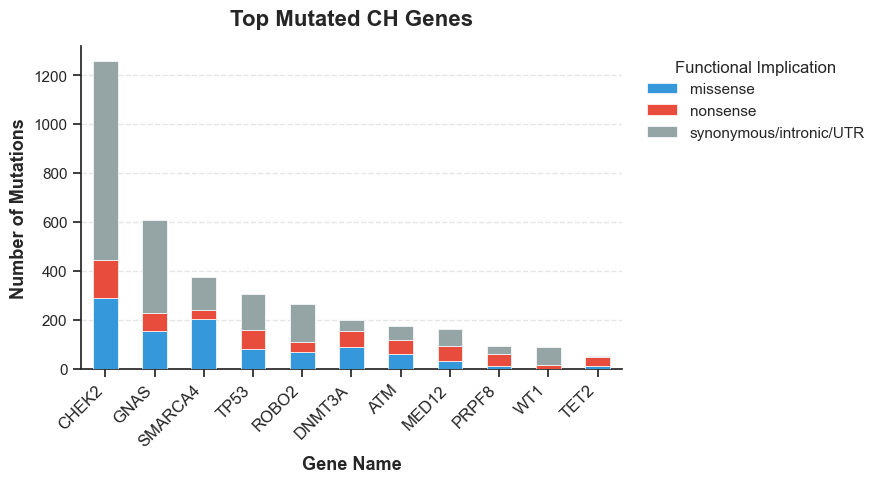

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean base style
sns.set_theme(style="ticks")

# ── 1. Smartly Load the VEP File ───────────────────────────────────────
file_path = "ch_variants_annotated.tsv" 

print("Scanning VEP file for headers...")
with open(file_path, 'r') as f:
    for line in f:
        if line.startswith('#Uploaded_variation'):
            col_names = line.lstrip('#').strip().split('\t')
            break

df_vep = pd.read_csv(file_path, sep='\t', comment='#', names=col_names)

# ── 2. Extract Gene and Consequence ────────────────────────────────────
df_collapsed = df_vep[['SYMBOL', 'Consequence']].copy()
df_collapsed = df_collapsed.rename(columns={'SYMBOL': 'gene_name'})

# Drop NaN values, the VEP '-' artifact, and CHEK2
df_collapsed = df_collapsed.dropna(subset=['gene_name'])
df_collapsed = df_collapsed[~df_collapsed['gene_name'].isin(['-'])]

df_collapsed['consequence'] = df_collapsed['Consequence'].str.split(',').str[0]

# ── 3. Apply your mapping logic ────────────────────────────────────────
def map_consequence_to_category(cons):
    if cons == 'missense_variant':
        return 'missense'
    elif cons in ['synonymous_variant', '3_prime_UTR_variant', '5_prime_UTR_variant', 'intron_variant', 'non_coding_transcript_exon_variant']:
        return 'synonymous/intronic/UTR'
    else:
        return 'nonsense'

df_collapsed['mutation_type'] = df_collapsed['consequence'].apply(map_consequence_to_category)

# ── 4. Prepare data for plotting ───────────────────────────────────────
plot_df = df_collapsed.groupby(['gene_name', 'mutation_type']).size().unstack(fill_value=0)

# Calculate totals for sorting
plot_df['Total'] = plot_df.sum(axis=1)
plot_df = plot_df.sort_values(by='Total', ascending=False)

# ── NEW: Force top 9 + TET2 at the end ────────────────────────────────
# Get top 9 genes (excluding TET2 so we don't accidentally list it twice)
top_9_genes = [g for g in plot_df.index if g != 'TET2'][:10]

# Create our final exact order
final_gene_list = top_9_genes + ['TET2']

# If TET2 had literally 0 mutations and isn't in the dataframe at all, add a blank row for it
if 'TET2' not in plot_df.index:
    plot_df.loc['TET2'] = 0

# Subset and order the dataframe perfectly
plot_df = plot_df.loc[final_gene_list]

# Drop the 'Total' column so it doesn't get plotted
plot_df = plot_df.drop(columns=['Total'], errors='ignore')

# ── 5. Plotting ────────────────────────────────────────────────────────
color_map = {
    'missense': '#3498db',               # Blue
    'nonsense': '#e74c3c',               # Red
    'synonymous/intronic/UTR': '#95a5a6' # Gray
}

# Ensure the colors match the columns that actually exist in the data
plot_colors = [color_map.get(col, '#333333') for col in plot_df.columns]

ax = plot_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(9, 5),
    color=plot_colors,
    edgecolor='white',
    linewidth=0.5,
    zorder=3 
)

# Aesthetics
plt.title('Top Mutated CH Genes', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Mutations', fontsize=13, fontweight='bold')
plt.xlabel('Gene Name', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=11)

# Legend formatting
plt.legend(title='Functional Implication', title_fontsize='12', 
           bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, frameon=False)

# Clean up grid and borders
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
sns.despine(top=True, right=True)

plt.tight_layout()

plt.show()

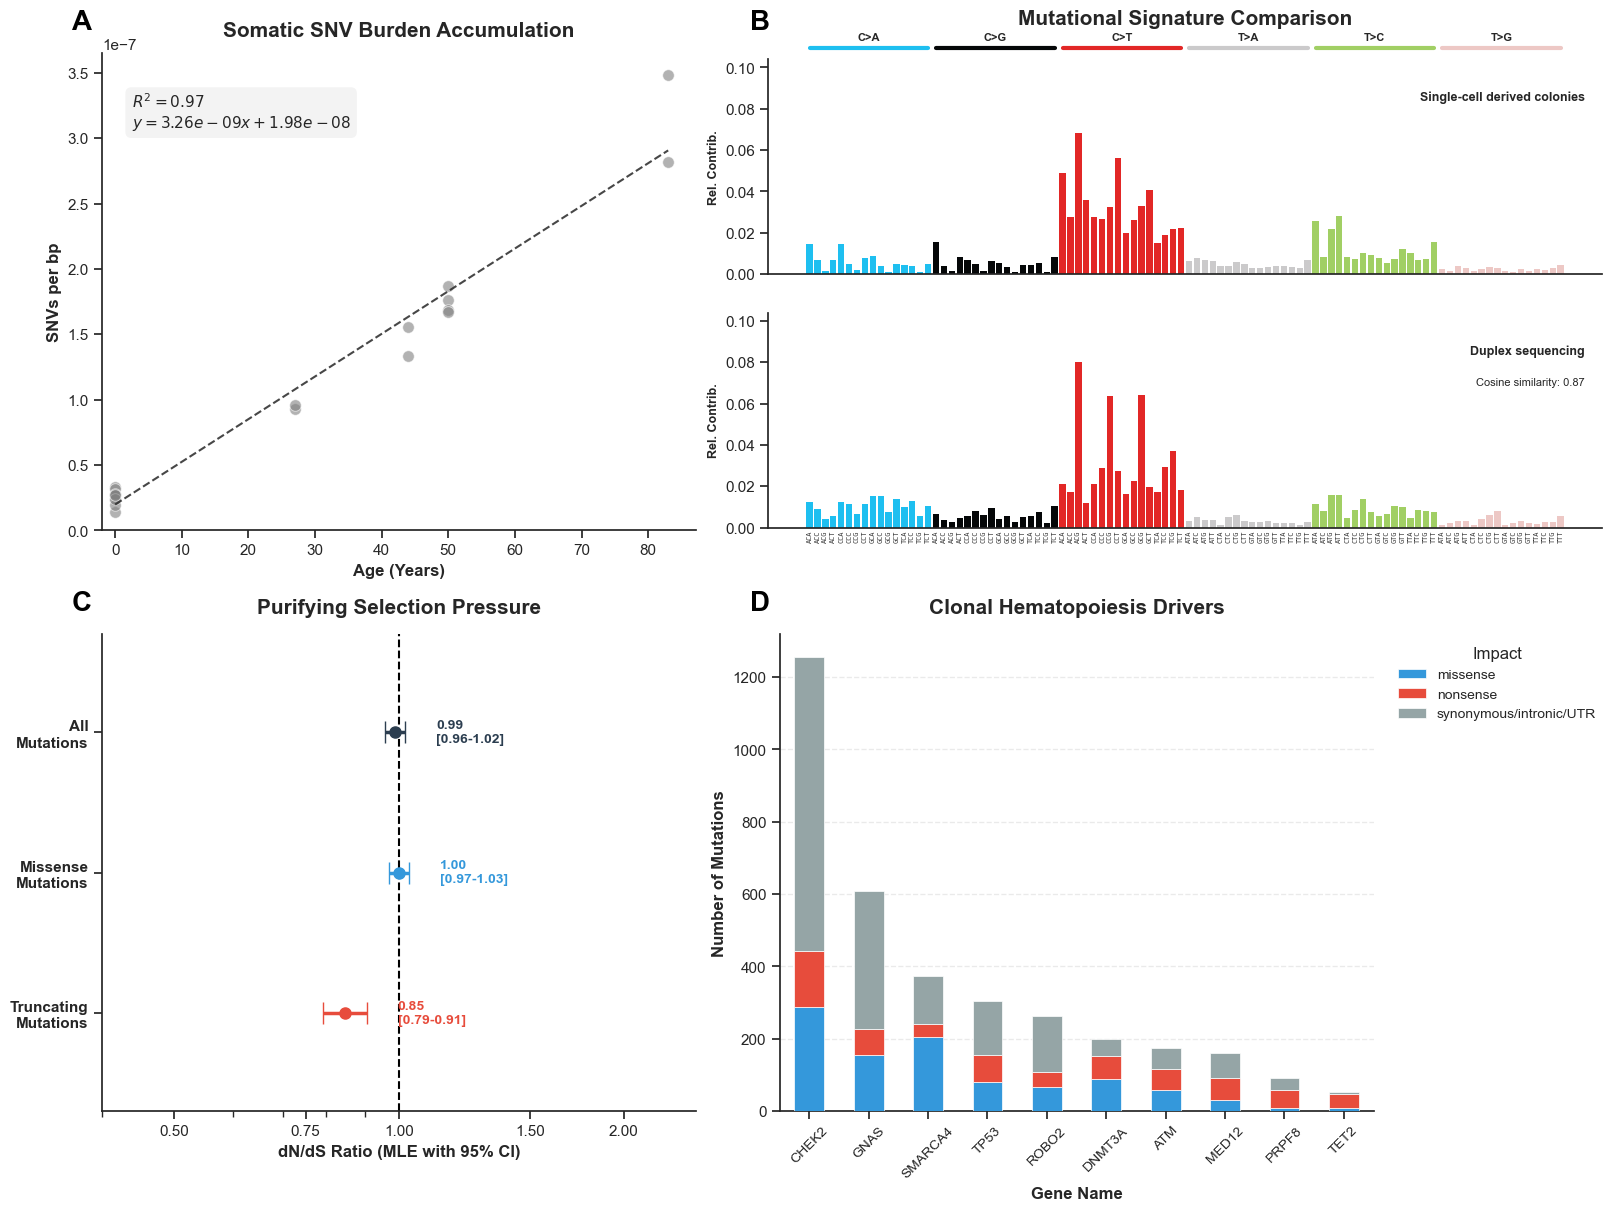

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import string
import matplotlib.gridspec as gridspec

# 1. Setup the Master Figure
# constrained_layout=True is MAGIC for multi-panel figures. It automatically 
# adjusts spacing so your titles, legends, and axis labels never overlap.
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), constrained_layout=True)

sns.set_theme(style="ticks")

# ==========================================
# PANEL A: Top Left (SNV Burden vs Age)
# ==========================================
ax_a = axs[0, 0]

# 1. Filter Data for T-cells and Cordblood
df_a = df_plot[df_plot['sample_type'].isin(['T_cells', 'cordblood'])].dropna(subset=['age', 'snv_burden'])

# 2. Scatter Plot
sns.scatterplot(
    data=df_a, 
    x='age', 
    y='snv_burden', 
    color='grey', 
    marker='o', 
    s=70, 
    alpha=0.6,
    ax=ax_a,
    zorder=2
)

# 3. Linear Regression Logic
x = df_a['age'].values
y = df_a['snv_burden'].values

if len(x) > 1:
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Calculate regression line points
    line_x = np.array([0, x.max()])
    line_y = slope * line_x + intercept
    
    # Plot the trend line
    ax_a.plot(line_x, line_y, color='#333333', linestyle='--', linewidth=1.5, alpha=0.9, zorder=3)
    
    # Statistics box: R^2 and the Equation (y = mx + b)
    # Using scientific notation for the small mutation rates common in SNV burden
    stats_text = f"$R^2 = {r_value**2:.2f}$\n$y = {slope:.2e}x + {intercept:.2e}$"
    
    ax_a.text(0.05, 0.92, stats_text, transform=ax_a.transAxes, 
              fontsize=11, verticalalignment='top', 
              bbox=dict(boxstyle="round,pad=0.4", edgecolor='none', facecolor='#f0f0f0', alpha=0.8))

# 4. Clean up Axes & Labels
ax_a.set_title("Somatic SNV Burden Accumulation", fontsize=15, fontweight='bold', pad=12)
ax_a.set_xlabel("Age (Years)", fontsize=12, fontweight='bold')
ax_a.set_ylabel("SNVs per bp", fontsize=12, fontweight='bold')

# Removed ax_a.grid() call to keep the background white/clean
ax_a.set_xlim(left=-2) 
ax_a.set_ylim(bottom=0)

# Final touch: ensure spines are clean
sns.despine(ax=ax_a)

# ==========================================
# PANEL B: Top Right (Mutational Signatures)
# ==========================================
ax_b_master = axs[0, 1]
ax_b_master.axis('off') 

# 1. GridSpec Setup
gs_b = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=ax_b_master.get_subplotspec(), 
                                        hspace=0.05, 
                                        height_ratios=[1, 1])

ax_b_ref = fig.add_subplot(gs_b[0, 0])
ax_b_smp = fig.add_subplot(gs_b[1, 0])

# --- Data Prep ---
mutation_classes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
colors = ['#1ebff0', '#050708', '#e22726', '#cbcacb', '#a1cf64', '#edc8c5']
bases = ['A', 'C', 'G', 'T']
# Generate the 96 context strings (e.g., ACA, ACC, ACG, ACT...)
contexts_96 = [f"{p5}{ref[0]}{p3}" for ref in mutation_classes for p5 in bases for p3 in bases]
x_positions = np.arange(96)

sample_prop = my_sample_profile / (np.sum(my_sample_profile) + 1e-9)
ref_prop = machado_profile / (np.sum(machado_profile) + 1e-9)
sim = 1 - cosine(sample_prop, ref_prop)

# --- Plotting ---
sub_axes = [ax_b_ref, ax_b_smp]
datasets = [(ref_prop, "Single-cell derived colonies", ""), 
            (sample_prop, "Duplex sequencing", f"Cosine similarity: {sim:.2f}")]

for ax, (data, title, sim_text) in zip(sub_axes, datasets):
    for i in range(6):
        start = i * 16
        end = (i + 1) * 16
        ax.bar(x_positions[start:end], data[start:end], color=colors[i], width=0.8, linewidth=0)
        
    ax.set_ylabel("Rel. Contrib.", fontsize=9, fontweight='bold')
    ax.text(0.98, 0.85, title, transform=ax.transAxes, ha='right', va='top', fontsize=9, fontweight='bold')
    if sim_text:
        ax.text(0.98, 0.70, sim_text, transform=ax.transAxes, ha='right', va='top', fontsize=8)
    
    ax.set_ylim(0, max(np.max(sample_prop), np.max(ref_prop)) * 1.3)
    ax.set_xticks([]) # Clear default ticks
    sns.despine(ax=ax)

# 2. Add the 96 Trinucleotide Context Labels to the BOTTOM plot
ax_b_smp.set_xticks(x_positions)
ax_b_smp.set_xticklabels(contexts_96, rotation=90, fontsize=5, family='monospace', color='#333333')
# Remove the tick marks themselves to keep it clean, leaving only the text
ax_b_smp.tick_params(axis='x', which='both', length=0, pad=2)

# 3. Mutation Class Labels (Above Top Plot)
y_max = ax_b_ref.get_ylim()[1]
for i, mut in enumerate(mutation_classes):
    center_x = (i * 16) + 7.5
    ax_b_ref.text(center_x, y_max * 1.08, mut, ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax_b_ref.plot([i * 16, (i + 1) * 16 - 1], [y_max * 1.05, y_max * 1.05], 
                  color=colors[i], lw=3, clip_on=False)

# 4. Final Alignment & Title
ax_b_ref.set_title("Mutational Signature Comparison", fontsize=15, fontweight='bold', pad=25)

ax_b_smp.set_xlabel(" ", labelpad=16) 

# Ensure the tick labels (trinucleotides) are pinned close to the axis
ax_b_smp.tick_params(axis='x', pad=2)
# ==========================================
# PANEL C: Bottom Left (dN/dS Forest Plot)
# ==========================================
ax_c = axs[1, 0]

# 1. Data Prep & Mapping
plot_data_c = df_dnds_global.copy()
order_map = {'wall': 2, 'wmis': 1, 'wtrunc': 0}
plot_data_c['order'] = plot_data_c['Mutation_Type'].map(order_map)
plot_data_c = plot_data_c.sort_values('order')

# COLOR SYNC: Match Panel D
color_map_c = {
    'wall': '#2c3e50',   # Navy
    'wmis': '#3498db',   # Blue (Missense)
    'wtrunc': '#e74c3c'  # Red (Truncating)
}
labels_c = {'wall': 'All\nMutations', 'wmis': 'Missense\nMutations', 'wtrunc': 'Truncating\nMutations'}

# 2. Reference Lines
ax_c.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, zorder=1)

# 3. Plotting
for idx, row in plot_data_c.iterrows():
    y = row['order']
    mle, low, high = row['MLE'], row['CI_low'], row['CI_high']
    col = color_map_c[row['Mutation_Type']]
    
    x_err = [[max(0, mle - low)], [max(0, high - mle)]]
    ax_c.errorbar(x=mle, y=y, xerr=x_err, fmt='o', color=col, ecolor=col, 
                  capsize=8, elinewidth=2.5, markersize=8, zorder=3)
    
    ax_c.text(high * 1.1, y, f"{mle:.2f}\n[{low:.2f}-{high:.2f}]", 
              va='center', fontsize=10, fontweight='bold', color=col)

# 4. X & Y Axis Aesthetics
ax_c.set_xscale('log')
ax_c.set_xlim(0.4, 2.5)
ax_c.set_xticks([0.5, 0.75, 1.0, 1.5, 2.0])
ax_c.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax_c.xaxis.set_minor_formatter(ticker.NullFormatter())
ax_c.set_yticks(plot_data_c['order'])
ax_c.set_yticklabels([labels_c[x] for x in plot_data_c['Mutation_Type']], fontsize=11, fontweight='bold')
ax_c.set_ylim(-0.7, 2.7)

ax_c.set_xlabel("dN/dS Ratio (MLE with 95% CI)", fontsize=12, fontweight='bold')
ax_c.set_title("Purifying Selection Pressure", fontsize=15, fontweight='bold', pad=15)
sns.despine(ax=ax_c, left=True)

# ==========================================
# PANEL D: Bottom Right (Top Mutated Genes)
# ==========================================
ax_d = axs[1, 1]

# 1. Prepare Data
df_collapsed_d = df_vep[['SYMBOL', 'Consequence']].copy().rename(columns={'SYMBOL': 'gene_name'})
df_collapsed_d = df_collapsed_d.dropna(subset=['gene_name'])
df_collapsed_d = df_collapsed_d[~df_collapsed_d['gene_name'].isin(['-'])]
df_collapsed_d['consequence'] = df_collapsed_d['Consequence'].str.split(',').str[0]
df_collapsed_d['mutation_type'] = df_collapsed_d['consequence'].apply(map_consequence_to_category)

plot_df_d = df_collapsed_d.groupby(['gene_name', 'mutation_type']).size().unstack(fill_value=0)
plot_df_d['Total'] = plot_df_d.sum(axis=1)
plot_df_d = plot_df_d.sort_values(by='Total', ascending=False)

top_9_genes = [g for g in plot_df_d.index if g != 'TET2'][:9]
final_gene_list = top_9_genes + ['TET2']
if 'TET2' not in plot_df_d.index: plot_df_d.loc['TET2'] = 0
plot_df_d = plot_df_d.loc[final_gene_list].drop(columns=['Total'], errors='ignore')

# 2. Plotting with SYNCED COLORS
# Note: 'nonsense' here corresponds to 'wtrunc' in Panel C
color_map_d = {
    'missense': '#3498db',               # Blue
    'nonsense': '#e74c3c',               # Red
    'synonymous/intronic/UTR': '#95a5a6' # Gray
}
plot_colors_d = [color_map_d.get(col, '#333333') for col in plot_df_d.columns]

plot_df_d.plot(kind='bar', stacked=True, ax=ax_d, color=plot_colors_d, edgecolor='white', linewidth=0.5, zorder=3)

# 3. Aesthetics
ax_d.set_title('Clonal Hematopoiesis Drivers', fontsize=15, fontweight='bold', pad=15)
ax_d.set_ylabel('Number of Mutations', fontsize=12, fontweight='bold')
ax_d.set_xlabel('Gene Name', fontsize=12, fontweight='bold')
ax_d.tick_params(axis='x', rotation=45, labelsize=10)
ax_d.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

ax_d.legend(title='Impact', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=10)
sns.despine(ax=ax_d)

# ==========================================
# ADD GRANT-STYLE A, B, C, D LABELS
# ==========================================
# This loops through your 4 axes and stamps a bold A, B, C, D in the top left corner of each
for n, ax in enumerate(axs.flat):
    ax.text(-0.05, 1.05, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold', color='black')
    
    # Despine every panel for that clean look
    sns.despine(ax=ax, top=True, right=True)

# ==========================================
# SAVE THE FINAL MASTERPIECE
# ==========================================
# Save as a PDF for perfect vector scaling in Illustrator/grant portals
plt.savefig('Master_Figure_1.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ==========================================
# CORRECTED DATA PREP FOR PANEL D
# ==========================================

# 1. Keep the essential columns, including the genomic coordinates and sample ID
# (You need the exact column names your VEP file uses for chr, pos, ref, alt, and sample)
# Assuming standard VEP columns: 'Location' (chr:pos), 'Allele', 'SYMBOL', 'Consequence'
df_vep_clean = df_vep[['Location', 'Allele', 'SYMBOL', 'Consequence']].copy()

# 2. Rename for consistency
df_vep_clean = df_vep_clean.rename(columns={'SYMBOL': 'gene_name'})

# 3. Drop missing genes and the '-' artifact
df_vep_clean = df_vep_clean.dropna(subset=['gene_name'])
df_vep_clean = df_vep_clean[~df_vep_clean['gene_name'].isin(['-'])]

# 4. THE FIX: Deduplicate! 
# If the same mutation exists at the same location with the same allele, keep only the first instance.
# (If you have a Sample ID column, add it to the subset list below: subset=['Location', 'Allele', 'SampleID'])
df_vep_dedup = df_vep_clean.drop_duplicates(subset=['Location', 'Allele', 'gene_name'])

# 5. Apply the consequence mapping
df_vep_dedup['consequence'] = df_vep_dedup['Consequence'].str.split(',').str[0]
df_vep_dedup['mutation_type'] = df_vep_dedup['consequence'].apply(map_consequence_to_category)

# 6. Group and plot (Now with true counts!)
plot_df_d = df_vep_dedup.groupby(['gene_name', 'mutation_type']).size().unstack(fill_value=0)
plot_df_d['Total'] = plot_df_d.sum(axis=1)
plot_df_d = plot_df_d.sort_values(by='Total', ascending=False)

print(f"Total unique mutations after deduplication: {len(df_vep_dedup)}")

Total unique mutations after deduplication: 254


/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/514928106.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vep_dedup['consequence'] = df_vep_dedup['Consequence'].str.split(',').str[0]
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_33546/514928106.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vep_dedup['mutation_type'] = df_vep_dedup['consequence'].apply(map_consequence_to_category)


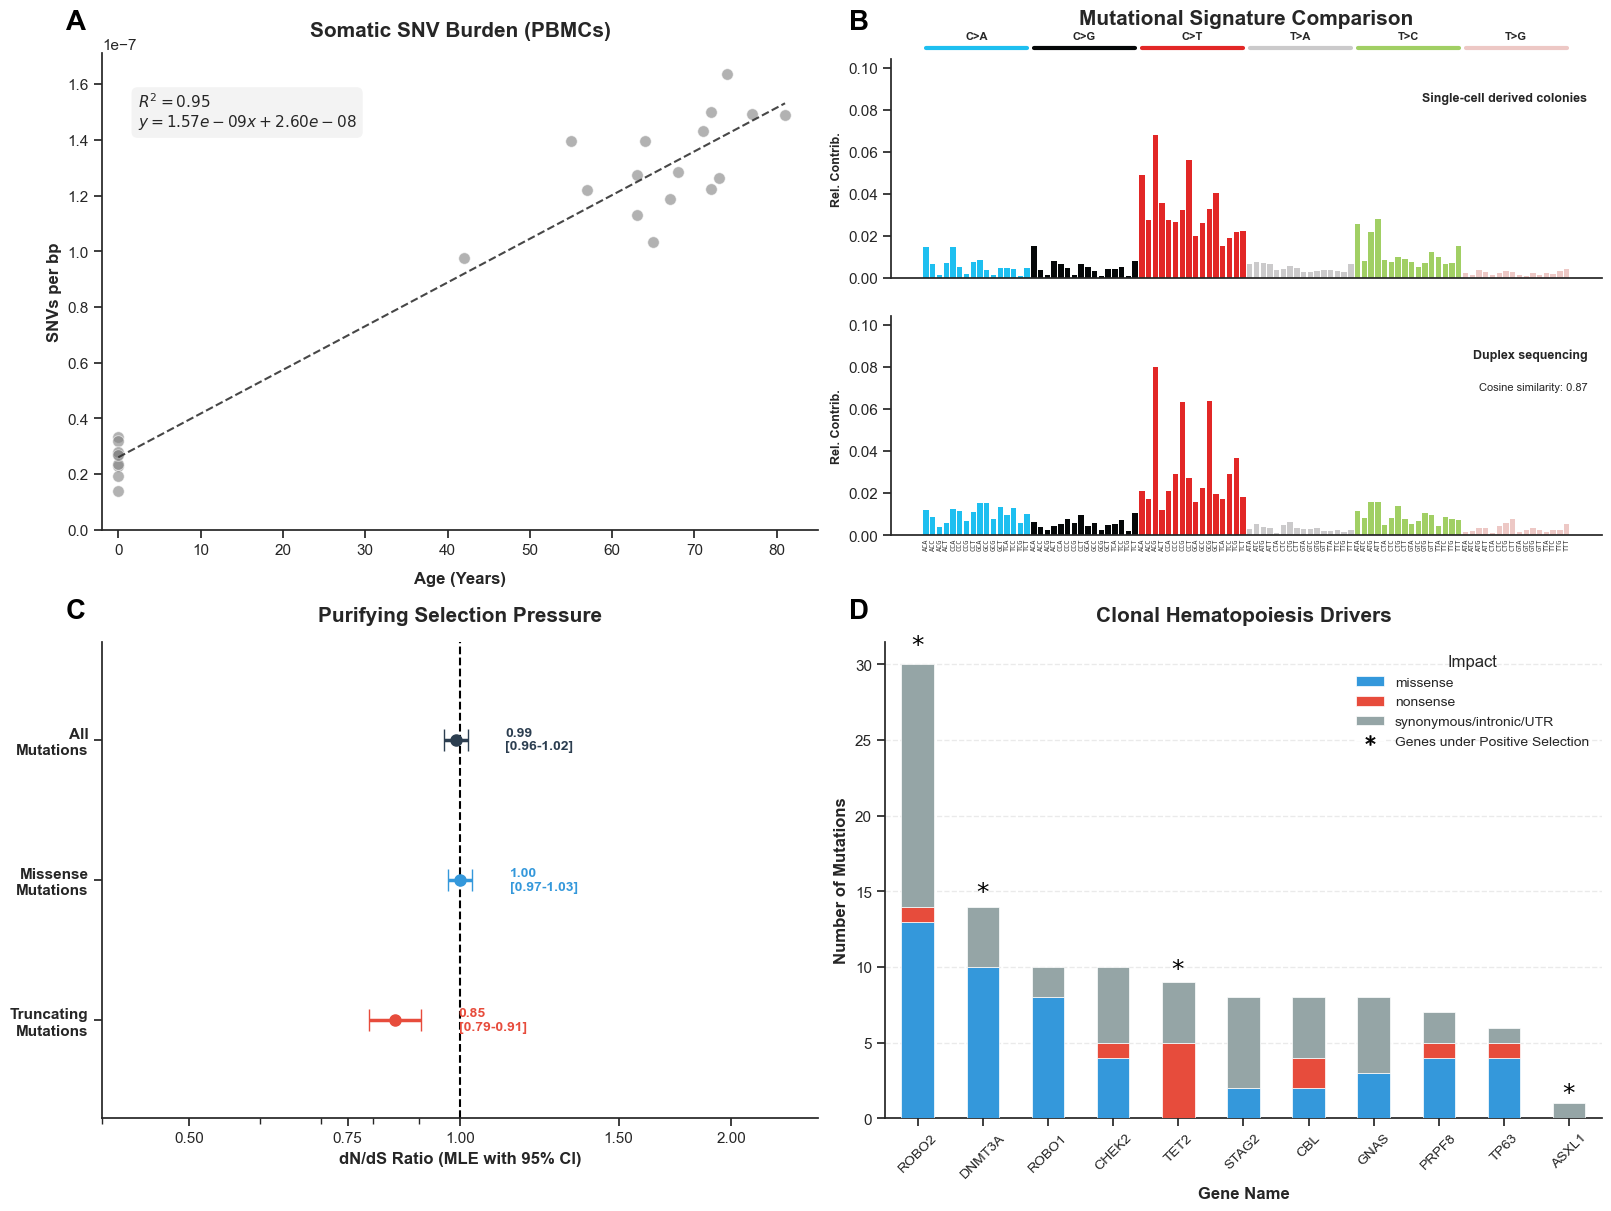

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import string
import matplotlib.gridspec as gridspec

# 1. Setup the Master Figure
# constrained_layout=True is MAGIC for multi-panel figures. It automatically 
# adjusts spacing so your titles, legends, and axis labels never overlap.
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), constrained_layout=True)

sns.set_theme(style="ticks")

# ==========================================
# PANEL A: Top Left (SNV Burden vs Age)
# ==========================================
ax_a = axs[0, 0]

# 1. Filter Data for PBMCs and Cordblood
# Swapped 'T_cells' for 'PBMCs' per your request
df_a = df_plot[df_plot['sample_type'].isin(['PBMCs', 'cordblood'])].dropna(subset=['age', 'snv_burden'])

# 2. Scatter Plot
sns.scatterplot(
    data=df_a, 
    x='age', 
    y='snv_burden', 
    color='grey', 
    marker='o', 
    s=70, 
    alpha=0.6,
    ax=ax_a,
    zorder=2
)

# 3. Linear Regression Logic
x = df_a['age'].values
y = df_a['snv_burden'].values

if len(x) > 1:
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Calculate regression line points
    line_x = np.array([0, x.max()])
    line_y = slope * line_x + intercept
    
    # Plot the trend line
    ax_a.plot(line_x, line_y, color='#333333', linestyle='--', linewidth=1.5, alpha=0.9, zorder=3)
    
    # Statistics box: R^2 and the Equation (y = mx + b)
    stats_text = f"$R^2 = {r_value**2:.2f}$\n$y = {slope:.2e}x + {intercept:.2e}$"
    
    ax_a.text(0.05, 0.92, stats_text, transform=ax_a.transAxes, 
              fontsize=11, verticalalignment='top', 
              bbox=dict(boxstyle="round,pad=0.4", edgecolor='none', facecolor='#f0f0f0', alpha=0.8))

# 4. Clean up Axes & Labels
ax_a.set_title("Somatic SNV Burden (PBMCs)", fontsize=15, fontweight='bold', pad=12)

# ALIGNMENT FIX: Use a specific labelpad to match the vertical space in Panel B
ax_a.set_xlabel("Age (Years)", fontsize=12, fontweight='bold', labelpad=10)
ax_a.set_ylabel("SNVs per bp", fontsize=12, fontweight='bold')

ax_a.set_xlim(left=-2) 
ax_a.set_ylim(bottom=0)

# Final touch: ensure spines are clean
sns.despine(ax=ax_a)

# ==========================================
# PANEL B: Top Right (Mutational Signatures)
# ==========================================
ax_b_master = axs[0, 1]
ax_b_master.axis('off') 

# 1. GridSpec Setup
gs_b = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=ax_b_master.get_subplotspec(), 
                                        hspace=0.05, 
                                        height_ratios=[1, 1])

ax_b_ref = fig.add_subplot(gs_b[0, 0])
ax_b_smp = fig.add_subplot(gs_b[1, 0])

# --- Data Prep ---
mutation_classes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
colors = ['#1ebff0', '#050708', '#e22726', '#cbcacb', '#a1cf64', '#edc8c5']
bases = ['A', 'C', 'G', 'T']
# Generate the 96 context strings (e.g., ACA, ACC, ACG, ACT...)
contexts_96 = [f"{p5}{ref[0]}{p3}" for ref in mutation_classes for p5 in bases for p3 in bases]
x_positions = np.arange(96)

sample_prop = my_sample_profile / (np.sum(my_sample_profile) + 1e-9)
ref_prop = machado_profile / (np.sum(machado_profile) + 1e-9)
sim = 1 - cosine(sample_prop, ref_prop)

# --- Plotting ---
sub_axes = [ax_b_ref, ax_b_smp]
datasets = [(ref_prop, "Single-cell derived colonies", ""), 
            (sample_prop, "Duplex sequencing", f"Cosine similarity: {sim:.2f}")]

for ax, (data, title, sim_text) in zip(sub_axes, datasets):
    for i in range(6):
        start = i * 16
        end = (i + 1) * 16
        ax.bar(x_positions[start:end], data[start:end], color=colors[i], width=0.8, linewidth=0)
        
    ax.set_ylabel("Rel. Contrib.", fontsize=9, fontweight='bold')
    ax.text(0.98, 0.85, title, transform=ax.transAxes, ha='right', va='top', fontsize=9, fontweight='bold')
    if sim_text:
        ax.text(0.98, 0.70, sim_text, transform=ax.transAxes, ha='right', va='top', fontsize=8)
    
    ax.set_ylim(0, max(np.max(sample_prop), np.max(ref_prop)) * 1.3)
    ax.set_xticks([]) # Clear default ticks
    sns.despine(ax=ax)

# 2. Add the 96 Trinucleotide Context Labels to the BOTTOM plot
ax_b_smp.set_xticks(x_positions)
ax_b_smp.set_xticklabels(contexts_96, rotation=90, fontsize=5, family='monospace', color='#333333')
# Remove the tick marks themselves to keep it clean, leaving only the text
ax_b_smp.tick_params(axis='x', which='both', length=0, pad=2)

# 3. Mutation Class Labels (Above Top Plot)
y_max = ax_b_ref.get_ylim()[1]
for i, mut in enumerate(mutation_classes):
    center_x = (i * 16) + 7.5
    ax_b_ref.text(center_x, y_max * 1.08, mut, ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax_b_ref.plot([i * 16, (i + 1) * 16 - 1], [y_max * 1.05, y_max * 1.05], 
                  color=colors[i], lw=3, clip_on=False)

# 4. Final Alignment & Title
ax_b_ref.set_title("Mutational Signature Comparison", fontsize=15, fontweight='bold', pad=25)

ax_b_smp.set_xlabel(" ", labelpad=16) 

# Ensure the tick labels (trinucleotides) are pinned close to the axis
ax_b_smp.tick_params(axis='x', pad=2)
# ==========================================
# PANEL C: Bottom Left (dN/dS Forest Plot)
# ==========================================
ax_c = axs[1, 0]

# 1. Data Prep & Mapping
plot_data_c = df_dnds_global.copy()
order_map = {'wall': 2, 'wmis': 1, 'wtrunc': 0}
plot_data_c['order'] = plot_data_c['Mutation_Type'].map(order_map)
plot_data_c = plot_data_c.sort_values('order')

# COLOR SYNC: Match Panel D
color_map_c = {
    'wall': '#2c3e50',   # Navy
    'wmis': '#3498db',   # Blue (Missense)
    'wtrunc': '#e74c3c'  # Red (Truncating)
}
labels_c = {'wall': 'All\nMutations', 'wmis': 'Missense\nMutations', 'wtrunc': 'Truncating\nMutations'}

# 2. Reference Lines
ax_c.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, zorder=1)

# 3. Plotting
for idx, row in plot_data_c.iterrows():
    y = row['order']
    mle, low, high = row['MLE'], row['CI_low'], row['CI_high']
    col = color_map_c[row['Mutation_Type']]
    
    x_err = [[max(0, mle - low)], [max(0, high - mle)]]
    ax_c.errorbar(x=mle, y=y, xerr=x_err, fmt='o', color=col, ecolor=col, 
                  capsize=8, elinewidth=2.5, markersize=8, zorder=3)
    
    ax_c.text(high * 1.1, y, f"{mle:.2f}\n[{low:.2f}-{high:.2f}]", 
              va='center', fontsize=10, fontweight='bold', color=col)

# 4. X & Y Axis Aesthetics
ax_c.set_xscale('log')
ax_c.set_xlim(0.4, 2.5)
ax_c.set_xticks([0.5, 0.75, 1.0, 1.5, 2.0])
ax_c.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax_c.xaxis.set_minor_formatter(ticker.NullFormatter())
ax_c.set_yticks(plot_data_c['order'])
ax_c.set_yticklabels([labels_c[x] for x in plot_data_c['Mutation_Type']], fontsize=11, fontweight='bold')
ax_c.set_ylim(-0.7, 2.7)

ax_c.set_xlabel("dN/dS Ratio (MLE with 95% CI)", fontsize=12, fontweight='bold')
ax_c.set_title("Purifying Selection Pressure", fontsize=15, fontweight='bold', pad=15)
sns.despine(ax=ax_c, left=True)

# ==========================================
# PANEL D: Bottom Right (Top Mutated Genes)
# ==========================================
from matplotlib.lines import Line2D # Add this to your imports at the top if not there

ax_d = axs[1, 1]

# --- 1. Load Data & Prepare Plot DF ---
df_collapsed_d = df_vep_dedup[['gene_name', 'Consequence']].copy()

df_collapsed_d = df_collapsed_d.dropna(subset=['gene_name'])
df_collapsed_d = df_collapsed_d[~df_collapsed_d['gene_name'].isin(['-'])]
df_collapsed_d['consequence'] = df_collapsed_d['Consequence'].str.split(',').str[0]
df_collapsed_d['mutation_type'] = df_collapsed_d['consequence'].apply(map_consequence_to_category)

plot_df_d = df_collapsed_d.groupby(['gene_name', 'mutation_type']).size().unstack(fill_value=0)
plot_df_d['Total'] = plot_df_d.sum(axis=1)
plot_df_d = plot_df_d.sort_values(by='Total', ascending=False)

# Top 10 + ASXL1
top_10_genes = list(plot_df_d.index[:10])

if 'ASXL1' in top_10_genes:
    final_gene_list = top_10_genes
else:
    final_gene_list = top_10_genes + ['ASXL1']

if 'ASXL1' not in plot_df_d.index: 
    plot_df_d.loc['ASXL1'] = 0

plot_df_d = plot_df_d.loc[final_gene_list].drop(columns=['Total'], errors='ignore')

# --- 2. Plotting the Stacked Bars ---
color_map_d = {'missense': '#3498db', 'nonsense': '#e74c3c', 'synonymous/intronic/UTR': '#95a5a6'}
plot_colors_d = [color_map_d.get(col, '#333333') for col in plot_df_d.columns]

plot_df_d.plot(kind='bar', stacked=True, ax=ax_d, color=plot_colors_d, edgecolor='white', linewidth=0.5, zorder=3)

# --- 3. Add dNdScv Significance Asterisks ---
df_sel = pd.read_csv("ch_genes_dndscv_results.csv")
sig_genes = df_sel[df_sel['pglobal_cv'] < 0.05]['gene_name'].tolist()

for i, gene in enumerate(plot_df_d.index):
    if gene in sig_genes:
        y_max = plot_df_d.loc[gene].sum()
        ax_d.text(i, y_max * 1.02, '$*$', ha='center', va='bottom', 
                  fontsize=18, color='black')

# --- 4. Aesthetics & Custom Legend ---
ax_d.set_title('Clonal Hematopoiesis Drivers', fontsize=15, fontweight='bold', pad=15)
ax_d.set_ylabel('Number of Mutations', fontsize=12, fontweight='bold')
ax_d.set_xlabel('Gene Name', fontsize=12, fontweight='bold')
ax_d.tick_params(axis='x', rotation=45, labelsize=10)
ax_d.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# Grab the current handles and labels from the bar chart
handles, labels = ax_d.get_legend_handles_labels()

# 1. FIX THE ASTERISK: Use the literal text character '$*$' instead of the geometric star '*'
from matplotlib.lines import Line2D
asterisk_proxy = Line2D([0], [0], color='w', marker='$*$', markerfacecolor='black', 
                        markeredgecolor='black', markeredgewidth=0.5, markersize=7)

# Append the custom marker to the legend items
handles.append(asterisk_proxy)
labels.append('Genes under Positive Selection')

# 2. MOVE LEGEND INSIDE: Changed 'loc' to 'upper right' and removed 'bbox_to_anchor'
ax_d.legend(handles=handles, labels=labels, title='Impact', 
            loc='upper right', frameon=False, fontsize=10)

sns.despine(ax=ax_d)

# ==========================================
# ADD GRANT-STYLE A, B, C, D LABELS
# ==========================================
# This loops through your 4 axes and stamps a bold A, B, C, D in the top left corner of each
for n, ax in enumerate(axs.flat):
    ax.text(-0.05, 1.05, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold', color='black')
    
    # Despine every panel for that clean look
    sns.despine(ax=ax, top=True, right=True)

# ==========================================
# SAVE THE FINAL MASTERPIECE
# ==========================================
# Save as a PDF for perfect vector scaling in Illustrator/grant portals
plt.savefig('Master_Figure_2.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Create the standard 5-column dataframe for dNdScv
df_dndscv_input = df_ch_vars[['sampleID', 'chr', 'pos', 'ref', 'mut']].copy()

# Ensure chromosome names don't have 'chr' prefix for standard dNdScv hg19/hg38 references
df_dndscv_input['chr'] = df_dndscv_input['chr'].astype(str).str.replace('chr', '')

# Export to CSV
df_dndscv_input.to_csv("ch_mutations_for_dndscv.csv", index=False)
print("Exported dNdScv input.")

Exported dNdScv input.
